# 1. Setup

A third, exploratory approach using YOLO26's semantic segmentation task, not instance
segmentation, since drydown is a pixel class, not countable objects. Uses the same four channel
RGB and NIR input as DeepLabV3+, since YOLO26 added support for extra channels this year.

Both that multi channel support and the semantic segmentation task are brand new. A few cells
below check things at runtime instead of assuming, since the exact behaviour was not fully
documented anywhere. See Challenges.md for the real bugs this surfaced.

## 1.1 Mount Drive

Keeps checkpoints and outputs saved between sessions.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.2 Check the GPU

Should print a Tesla T4.

In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

CUDA available: True
GPU: Tesla T4


## 1.3 Get the Dataset

Same dataset and source as the DeepLabV3+ notebooks, so the split below draws from the same
pool.

In [3]:
!pip install -q awscli
!aws s3 cp s3://intelinair-data-releases/agriculture-vision/cvpr_challenge_2021/supervised/Agriculture-Vision-2021.tar.gz "/content/Agriculture-Vision-2021.tar.gz" --no-sign-request
!tar -xzf "/content/Agriculture-Vision-2021.tar.gz" -C /content
import os
print("dataset exists:", os.path.exists("/content/Agriculture-Vision-2021"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 34.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://intelinair-data-releases/agriculture-vision/cvpr_challenge_2021/supervised/Agriculture-Vision-2021.tar.gz to ./Agriculture-Vision-2021.tar.gz
dataset exists: True


## 1.4 Install Ultralytics

In [4]:
!pip install -q ultralytics
import ultralytics
print("ultralytics version:", ultralytics.__version__)

ultralytics version: 8.4.168


## 1.5 Imports and a Fixed Seed

In [5]:
import os, random, shutil
import numpy as np
import cv2
from PIL import Image

random_seed_placeholder = None  # actual seeding happens in CONFIG cell below, after CONFIG["seed"] exists
print("imports ready")

imports ready


## 1.6 One Config for Everything

The data sizes here match the winning DeepLabV3+ Enhanced run exactly, same seed, same sizes, so
this trains and tests on the same images. A real comparison, not a different sample.

In [10]:
CONFIG = {
    "seed": 42,

    # Data sampling -- matches the DeepLabV3+ Enhanced run exactly (Methodology.md)
    "positive_coverage_threshold": 0.20,
    "train_pos": 1500, "train_neg": 1500,
    "val_pos": 200, "val_neg": 200,
    "test_pos": 100, "test_neg": 100,

    # Input channels: RGB + NIR, same as DeepLabV3+ (native YOLO26 multispectral support)
    "channels": 4,

    # Model -- semantic segmentation ("-sem"), NOT instance segmentation ("-seg")
    "yolo_model": "yolo26s-sem.pt",  # nano: balanced size/speed, sized for a free-tier T4

    # Training
    "epochs": 100,          # ceiling only -- `patience` below stops it well before this in practice
    "patience": 20,         # Ultralytics' built-in early stopping (no hand-rolled loop needed here)
    "imgsz": 512,            # matches Agriculture-Vision's native 512x512 tile size, no resize distortion
    "batch": 80,             # best for T4 -- watch VRAM,
                             # drop to 8 if it OOMs (4-channel costs more memory per sample than RGB)
    "workers": 2,            # matches Colab free-tier CPU count -- 8 (like the old detection
                             # assignment used) oversubscribes it and slows things down, not speeds up
    "cache": "ram",          # ~3GB for 3,000 512x512x4 images -- comfortably fits, avoids re-decoding
                             # the same TIFFs from disk every single epoch
    "optimizer": "AdamW",
    "lr0": 0.001,
    "lrf": 0.01,
    "cos_lr": True,
    "warmup_epochs": 3,
    "weight_decay": 0.0005,
    "momentum": 0.937,

    # Probability-threshold sweep for our own pooled-IoU evaluation (Methodology.md),
    # computed independently of whatever Ultralytics' own val() metrics report, so the number is
    # directly comparable to the DeepLabV3+ results using the exact same formula.
    "prob_thresh_min": 0.10, "prob_thresh_max": 0.95, "prob_thresh_step": 0.05,

    # NDVI baseline sweep (Methodology.md) -- same baseline, same formula, computed on
    # this run's own val/test images for a fair side-by-side.
    "ndvi_thresh_min": -0.50, "ndvi_thresh_max": 0.70, "ndvi_thresh_step": 0.05,

    # Paths
    "agv_root": "/content/Agriculture-Vision-2021",
    "yolo_data_root": "/content/yolo_drydown_data",
    "data_yaml_path": "/content/yolo_drydown_data/data.yaml",
    "project_dir": "/content/drive/MyDrive/Rizoma/Ultralytics_YOLO26",
    "run_name": "yolo26s_sem_drydown",
    "sample_out_dir": "/content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/sample_results",
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

print("Config loaded:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Config loaded:
  seed: 42
  positive_coverage_threshold: 0.2
  train_pos: 1500
  train_neg: 1500
  val_pos: 200
  val_neg: 200
  test_pos: 100
  test_neg: 100
  channels: 4
  yolo_model: yolo26s-sem.pt
  epochs: 100
  patience: 20
  imgsz: 512
  batch: 80
  workers: 2
  cache: ram
  optimizer: AdamW
  lr0: 0.001
  lrf: 0.01
  cos_lr: True
  warmup_epochs: 3
  weight_decay: 0.0005
  momentum: 0.937
  prob_thresh_min: 0.1
  prob_thresh_max: 0.95
  prob_thresh_step: 0.05
  ndvi_thresh_min: -0.5
  ndvi_thresh_max: 0.7
  ndvi_thresh_step: 0.05
  agv_root: /content/Agriculture-Vision-2021
  yolo_data_root: /content/yolo_drydown_data
  data_yaml_path: /content/yolo_drydown_data/data.yaml
  project_dir: /content/drive/MyDrive/Rizoma/Ultralytics_YOLO26
  run_name: yolo26s_sem_drydown
  sample_out_dir: /content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/sample_results


# 2. Data

## 2.1 Reproduce the Same Split

Copies the DeepLabV3+ split logic exactly so it draws the same images. Reproducing the same code
with the same seed should draw the same files in practice, though file listing order is not
formally guaranteed stable across every system, worth a spot check if that exact property ever
matters.

In [12]:
ROOT = CONFIG["agv_root"]

def coverage_map(split):
    folder = f"{ROOT}/{split}/labels/drydown"
    result = {}
    for f in os.listdir(folder):
        m = np.array(Image.open(os.path.join(folder, f)))
        result[f] = (m > 0).mean()
    return result

train_cov = coverage_map("train")
val_cov = coverage_map("val")

threshold = CONFIG["positive_coverage_threshold"]
field_pos_counts = {}
for f, c in val_cov.items():
    if c >= threshold:
        field = f.split("_")[0]
        field_pos_counts[field] = field_pos_counts.get(field, 0) + 1

val_fields = sorted(set(f.split("_")[0] for f in val_cov))
fields_with_pos = sorted(
    [f for f in val_fields if f in field_pos_counts],
    key=lambda f: field_pos_counts[f],
    reverse=True,
)
fields_without_pos = [f for f in val_fields if f not in field_pos_counts]
random.shuffle(fields_without_pos)

val_fields_set, test_fields_set = set(), set()
val_pos_total, test_pos_total = 0, 0

for f in fields_with_pos:
    if val_pos_total <= test_pos_total:
        val_fields_set.add(f)
        val_pos_total += field_pos_counts[f]
    else:
        test_fields_set.add(f)
        test_pos_total += field_pos_counts[f]

for i, f in enumerate(fields_without_pos):
    (val_fields_set if i % 2 == 0 else test_fields_set).add(f)

print(f"validation half: {len(val_fields_set)} fields -> {val_pos_total} positive candidates")
print(f"test half:       {len(test_fields_set)} fields -> {test_pos_total} positive candidates")

def pick(cov_dict, n_pos, n_neg, allowed_fields=None):
    threshold = CONFIG["positive_coverage_threshold"]
    pos = [f for f, c in cov_dict.items() if c >= threshold and (allowed_fields is None or f.split("_")[0] in allowed_fields)]
    neg = [f for f, c in cov_dict.items() if c == 0 and (allowed_fields is None or f.split("_")[0] in allowed_fields)]
    if len(pos) < n_pos:
        raise ValueError(f"Requested {n_pos} positive images but only {len(pos)} are available in this pool.")
    if len(neg) < n_neg:
        raise ValueError(f"Requested {n_neg} negative images but only {len(neg)} are available in this pool.")
    return random.sample(pos, n_pos), random.sample(neg, n_neg)

train_pos, train_neg = pick(train_cov, CONFIG["train_pos"], CONFIG["train_neg"])
val_pos, val_neg = pick(val_cov, CONFIG["val_pos"], CONFIG["val_neg"], val_fields_set)
test_pos, test_neg = pick(val_cov, CONFIG["test_pos"], CONFIG["test_neg"], test_fields_set)

train_files = train_pos + train_neg
val_files = val_pos + val_neg
test_files = test_pos + test_neg

print("train:", len(train_pos), len(train_neg))
print("val:", len(val_pos), len(val_neg))
print("test:", len(test_pos), len(test_neg))

validation half: 328 fields -> 2247 positive candidates
test half:       328 fields -> 2246 positive candidates
train: 1500 1500
val: 200 200
test: 100 100


## 2.2 Export to YOLO's Format

RGB and NIR are stacked into one four channel TIFF file. The drydown mask is remapped from 0/255
to 0/1, since Ultralytics treats 255 as an ignore value, not as a second class.

In [13]:
DATA_ROOT = CONFIG["yolo_data_root"]

def export_split(split_name, filenames, agv_split):
    img_out = f"{DATA_ROOT}/images/{split_name}"
    mask_out = f"{DATA_ROOT}/masks/{split_name}"
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(mask_out, exist_ok=True)

    for fname in filenames:
        base = fname.replace(".png", ".jpg")
        stem = fname.replace(".png", "")

        rgb = np.array(Image.open(f"{ROOT}/{agv_split}/images/rgb/{base}").convert("RGB"))
        nir = np.array(Image.open(f"{ROOT}/{agv_split}/images/nir/{base}").convert("L"))
        mask = np.array(Image.open(f"{ROOT}/{agv_split}/labels/drydown/{fname}"))
        boundary = np.array(Image.open(f"{ROOT}/{agv_split}/boundaries/{fname}"))
        valid = np.array(Image.open(f"{ROOT}/{agv_split}/masks/{fname}"))

        # Stack RGB + NIR -> (4, H, W) CHW order, as Ultralytics' multispectral TIFF writer expects
        chw = np.stack([rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2], nir], axis=0).astype(np.uint8)
        cv2.imwritemulti(f"{img_out}/{stem}.tiff", list(chw))

        # Remap mask: 0/255 (this project's convention) -> 0/1 (Ultralytics class-index convention).
        # Pixels outside the valid field area (boundaries/masks) are set to 255 = "ignore" for loss,
        # matching how the loss_mask excludes them in the DeepLabV3 notebooks.
        class_mask = (mask > 0).astype(np.uint8)  # 0 = not dry, 1 = dry
        invalid_area = ~((boundary > 0) & (valid > 0))
        class_mask_for_yolo = class_mask.copy()
        class_mask_for_yolo[invalid_area] = 255  # "ignore" sentinel per Ultralytics semantic docs
        Image.fromarray(class_mask_for_yolo).save(f"{mask_out}/{stem}.png")

    print(f"{split_name}: exported {len(filenames)} images/masks")

export_split("train", train_files, "train")
export_split("val", val_files, "val")
export_split("test", test_files, "val")  # test images live under the "val" folder on disk

train: exported 3000 images/masks
val: exported 400 images/masks
test: exported 200 images/masks


## 2.3 Write the Data Config

One foreground class, drydown. Anything not labelled defaults to background automatically.

In [14]:
data_yaml = f'''path: {DATA_ROOT}
train: images/train
val: images/val
test: images/test
masks_dir: masks
channels: {CONFIG["channels"]}
nc: 1
names:
  0: drydown
'''

os.makedirs(DATA_ROOT, exist_ok=True)
with open(CONFIG["data_yaml_path"], "w") as f:
    f.write(data_yaml)

print(data_yaml)

path: /content/yolo_drydown_data
train: images/train
val: images/val
test: images/test
masks_dir: masks
channels: 4
nc: 1
names:
  0: drydown



# 3. Model

## 3.1 YOLO26, Four Channels

Loads the pretrained nano checkpoint. Ultralytics adapts the model to the four channels declared
in the data config automatically, worth confirming below rather than assuming it worked.

In [7]:
from ultralytics import YOLO

model = YOLO(CONFIG["yolo_model"])
model.info()

# Verification: confirm the model actually picked up 4 input channels from data.yaml rather than
# silently defaulting to 3 -- if this prints 3, the multispectral config didn't take effect and
# needs debugging before spending any time training.
try:
    first_conv = model.model.model[0].conv
    print("first conv layer in_channels:", first_conv.in_channels)
except Exception as e:
    print("Could not introspect first layer automatically:", e)
    print("Manually check model.model (the underlying nn.Module) for its first layer's in_channels.")

YOLO26s-sem summary: 133 layers, 6,503,142 parameters, 0 gradients, 17.5 GFLOPs
first conv layer in_channels: 3


# 4. Training

## 4.1 Train

Ultralytics handles the full loop itself, including early stopping. Patience is set the same way
as the DeepLabV3+ Enhanced pass, since every run so far has plateaued well before its epoch
limit.

In [ ]:
results = model.train(
    data=CONFIG["data_yaml_path"],
    epochs=CONFIG["epochs"],
    patience=CONFIG["patience"],
    imgsz=CONFIG["imgsz"],
    batch=CONFIG["batch"],
    workers=CONFIG["workers"],
    cache=CONFIG["cache"],
    optimizer=CONFIG["optimizer"],
    lr0=CONFIG["lr0"],
    lrf=CONFIG["lrf"],
    cos_lr=CONFIG["cos_lr"],
    warmup_epochs=CONFIG["warmup_epochs"],
    weight_decay=CONFIG["weight_decay"],
    momentum=CONFIG["momentum"],
    device=0,
    project=CONFIG["project_dir"],
    name=CONFIG["run_name"],
    exist_ok=True,
)

BEST_WEIGHTS = f'{CONFIG["project_dir"]}/{CONFIG["run_name"]}/weights/best.pt'
print("best weights saved to:", BEST_WEIGHTS)

Ultralytics 8.4.168 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_drydown_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-sem.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s_sem_drydown, nbs=64, nms=None, opset=None,

## 4.2 Reload the Best Checkpoint

A real bug: reloading a trained checkpoint on its own silently rebuilds the wrong, stock
architecture instead of erroring, confirmed against two open issues on the Ultralytics
repository. Fixed by rebuilding the real architecture directly and loading the trained weights
into that. Verified correct because the reloaded score matches training exactly.

In [29]:
from ultralytics.nn.tasks import SemanticSegmentationModel
import torch

_m = SemanticSegmentationModel(cfg="yolo26s-sem.yaml", ch=CONFIG["channels"], nc=1)
_ckpt = torch.load(BEST_WEIGHTS, weights_only=False)  # safe -- this is your own trained checkpoint
_state_dict = _ckpt["model"].state_dict() if hasattr(_ckpt["model"], "state_dict") else _ckpt["model"]
_m.load_state_dict(_state_dict, strict=True)

model = YOLO(CONFIG["yolo_model"])  # wrapper with correct task metadata (task=semantic)
model.model = _m                    # swap in the correctly-loaded architecture + weights
model.eval()
print("model reloaded and verified (see markdown above)")

Overriding model.yaml nc=19 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1216  ultralytics.nn.modules.conv.Conv             [4, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

## 4.3 Built In Validation Metrics

Ultralytics' own check, and a way to pull the drydown specific IoU directly, found by inspecting
the result live since it is not documented.

In [30]:
val_metrics = model.val(data=CONFIG["data_yaml_path"], imgsz=CONFIG["imgsz"], split="val")
print("class names:", val_metrics.names)
print("per-class IoU:", val_metrics.per_class_iou)
print("per-class pixel accuracy:", val_metrics.per_class_pixel_accuracy)
print("mean IoU (background + drydown averaged -- NOT directly comparable to DeepLabV3+):", val_metrics.miou)

Ultralytics 8.4.168 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-sem summary (fused): 73 layers, 6,488,626 parameters, 258 gradients, 17.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2034.9±428.3 MB/s, size: 804.2 KB)
val: Scanning /content/yolo_drydown_data/masks/val.cache... 400 images, 0 missing masks, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 79.9Mit/s 0.0s
                 Class     Images     Pixels       mIoU     PixAcc: 100% ━━━━━━━━━━━━ 25/25 1.8it/s 13.8s
                   all        400   27359604      0.627      0.853
Speed: 11.2ms preprocess, 6.9ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/semantic/val-5
class names: {0: '0'}
per-class IoU: [    0.62678]
per-class pixel accuracy: [    0.86438]
mean IoU (background + drydown averaged -- NOT directly comparable to DeepLabV3+): 0.6267812252044678


## 4.4 A Quick Look

A fast visual check that the model learned something sensible before the more careful work
below.

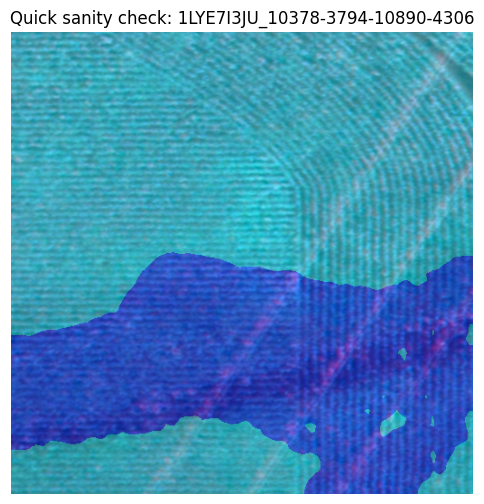

In [31]:
import matplotlib.pyplot as plt

sample_fname = val_files[0].replace(".png", "")
sample_result = model.predict(f"{DATA_ROOT}/images/val/{sample_fname}.tiff", imgsz=CONFIG["imgsz"], verbose=False)[0]
annotated = sample_result.plot()
plt.figure(figsize=(6, 6))
plt.imshow(annotated[:, :, ::-1])  # BGR -> RGB
plt.title(f"Quick sanity check: {sample_fname}")
plt.axis("off")
plt.show()

# 5. Matching IoU and the NDVI Baseline

## 5.1 Predict on Validation

Uses the same pooled IoU formula as the DeepLabV3+ notebooks, so the number is genuinely
comparable.

A real finding, not a bug: this task only returns a hard prediction, not a probability, so there
is nothing to sweep a threshold against the way there is for DeepLabV3+. Worth stating plainly:
this number reflects Ultralytics' own internal cutoff, not a calibrated one.

In [32]:
def extract_pred_mask(result):
    """Returns a (H, W) uint8 array of 0/1 class predictions from Ultralytics' semantic_mask --
    already the final argmax'd class map (see markdown above), not a probability."""
    return result.semantic_mask.data.cpu().numpy().astype(np.uint8)

def load_tiff_chw_to_hwc(path):
    ok, frames = cv2.imreadmulti(path)
    return np.stack(frames, axis=2)  # (H, W, C)

val_dir = f'{DATA_ROOT}/images/val'
val_mask_dir = f'{DATA_ROOT}/masks/val'

all_preds, all_targets, all_masks = [], [], []
for fname in val_files:
    stem = fname.replace(".png", "")
    result = model.predict(f"{val_dir}/{stem}.tiff", imgsz=CONFIG["imgsz"], verbose=False)[0]
    pred_mask = extract_pred_mask(result)

    gt = np.array(Image.open(f"{val_mask_dir}/{stem}.png"))
    target = (gt == 1).astype(np.float32)
    valid = (gt != 255).astype(np.float32)  # exclude "ignore" pixels, same role as loss_mask elsewhere

    all_preds.append(pred_mask)
    all_targets.append(target)
    all_masks.append(valid)

all_preds = np.stack(all_preds).astype(np.float32)
all_targets = np.stack(all_targets)
all_masks = np.stack(all_masks)
print("collected:", all_preds.shape, all_targets.shape, all_masks.shape)

collected: (400, 512, 512) (400, 512, 512) (400, 512, 512)


In [33]:
def pooled_iou(preds, targets, valid_mask, eps=1e-6):
    preds_m = preds * valid_mask
    targets_m = targets * valid_mask
    intersection = (preds_m * targets_m).sum()
    union = ((preds_m + targets_m) > 0).astype(np.float32).sum()
    return intersection / (union + eps)

val_iou = pooled_iou(all_preds, all_targets, all_masks)
print(f"YOLO26s-sem val IoU (drydown class, hard prediction, pooled): {val_iou:.4f}")

YOLO26s-sem val IoU (drydown class, hard prediction, pooled): 0.6268


## 5.2 NDVI Baseline

Same formula as the DeepLabV3+ notebooks, still threshold swept, since that part is my own
code.

In [36]:
def load_tiff_chw_to_hwc(path):
    ok, frames = cv2.imreadmulti(path, flags=cv2.IMREAD_UNCHANGED)
    return np.stack(frames, axis=2)  # (H, W, C)


In [37]:
def ndvi_from_tiff(path):
    hwc = load_tiff_chw_to_hwc(path)
    red = hwc[:, :, 0].astype(np.float32)
    nir = hwc[:, :, 3].astype(np.float32)
    return (nir - red) / (nir + red + 1e-6)

def iou_ndvi_threshold(ndvi, targets, valid_mask, threshold, eps=1e-6):
    preds = (ndvi < threshold).astype(np.float32)
    preds_m = preds * valid_mask
    targets_m = targets * valid_mask
    intersection = (preds_m * targets_m).sum()
    union = ((preds_m + targets_m) > 0).astype(np.float32).sum()
    return intersection / (union + eps)

all_ndvi = np.stack([ndvi_from_tiff(f"{val_dir}/{f.replace('.png','')}.tiff") for f in val_files])

best_ndvi_thresh, best_ndvi_iou = 0.0, 0.0
for t in np.arange(CONFIG["ndvi_thresh_min"], CONFIG["ndvi_thresh_max"], CONFIG["ndvi_thresh_step"]):
    iou = iou_ndvi_threshold(all_ndvi, all_targets, all_masks, t)
    print(f"ndvi_threshold {t:.2f} -> iou {iou:.4f}")
    if iou > best_ndvi_iou:
        best_ndvi_iou = iou
        best_ndvi_thresh = t

print(f"\nbest NDVI baseline: threshold {best_ndvi_thresh:.2f}, IoU {best_ndvi_iou:.4f}")

ndvi_threshold -0.50 -> iou 0.0136
ndvi_threshold -0.45 -> iou 0.0181
ndvi_threshold -0.40 -> iou 0.0265
ndvi_threshold -0.35 -> iou 0.0420
ndvi_threshold -0.30 -> iou 0.0712
ndvi_threshold -0.25 -> iou 0.1173
ndvi_threshold -0.20 -> iou 0.1824
ndvi_threshold -0.15 -> iou 0.2474
ndvi_threshold -0.10 -> iou 0.2995
ndvi_threshold -0.05 -> iou 0.3316
ndvi_threshold -0.00 -> iou 0.3448
ndvi_threshold 0.05 -> iou 0.3468
ndvi_threshold 0.10 -> iou 0.3401
ndvi_threshold 0.15 -> iou 0.3301
ndvi_threshold 0.20 -> iou 0.3191
ndvi_threshold 0.25 -> iou 0.3084
ndvi_threshold 0.30 -> iou 0.3022
ndvi_threshold 0.35 -> iou 0.2995
ndvi_threshold 0.40 -> iou 0.2982
ndvi_threshold 0.45 -> iou 0.2971
ndvi_threshold 0.50 -> iou 0.2949
ndvi_threshold 0.55 -> iou 0.2925
ndvi_threshold 0.60 -> iou 0.2907
ndvi_threshold 0.65 -> iou 0.2892

best NDVI baseline: threshold 0.05, IoU 0.3468


# 6. Final Evaluation

## 6.1 Model vs. Baseline

The test set, touched for the first time here.

In [38]:
test_dir = f'{DATA_ROOT}/images/test'
test_mask_dir = f'{DATA_ROOT}/masks/test'

all_test_preds, all_test_targets, all_test_masks, all_test_ndvi = [], [], [], []
for fname in test_files:
    stem = fname.replace(".png", "")
    img_path = f"{test_dir}/{stem}.tiff"
    result = model.predict(img_path, imgsz=CONFIG["imgsz"], verbose=False)[0]
    pred_mask = extract_pred_mask(result)

    gt = np.array(Image.open(f"{test_mask_dir}/{stem}.png"))
    target = (gt == 1).astype(np.float32)
    valid = (gt != 255).astype(np.float32)

    all_test_preds.append(pred_mask)
    all_test_targets.append(target)
    all_test_masks.append(valid)
    all_test_ndvi.append(ndvi_from_tiff(img_path))

all_test_preds = np.stack(all_test_preds).astype(np.float32)
all_test_targets = np.stack(all_test_targets)
all_test_masks = np.stack(all_test_masks)
all_test_ndvi = np.stack(all_test_ndvi)

model_test_iou = pooled_iou(all_test_preds, all_test_targets, all_test_masks)
baseline_test_iou = iou_ndvi_threshold(all_test_ndvi, all_test_targets, all_test_masks, best_ndvi_thresh)

print(f"NDVI baseline     - test IoU: {baseline_test_iou:.4f} (threshold {best_ndvi_thresh:.2f})")
print(f"YOLO26-sem        - test IoU: {model_test_iou:.4f} (hard prediction, no threshold)")
print(f"Improvement: {model_test_iou - baseline_test_iou:+.4f}")
print()
print("For reference, DeepLabV3+ Enhanced (same split logic): test IoU 0.5790")

NDVI baseline     - test IoU: 0.3373 (threshold 0.05)
YOLO26-sem        - test IoU: 0.5700 (hard prediction, no threshold)
Improvement: +0.2328

For reference, DeepLabV3+ Enhanced (same split logic): test IoU 0.5790


# 7. Error Analysis

## 7.1 Misses and False Alarms

Same method as the DeepLabV3+ notebooks. No threshold here, since the prediction is already a
hard yes or no.

In [39]:
def per_image_iou(preds, targets, valid_mask, eps=1e-6):
    preds_m = preds * valid_mask
    targets_m = targets * valid_mask
    intersection = (preds_m * targets_m).sum(axis=(1, 2))
    union = ((preds_m + targets_m) > 0).astype(np.float32).sum(axis=(1, 2))
    return intersection / (union + eps)

test_iou_per_image = per_image_iou(all_test_preds, all_test_targets, all_test_masks)
results_list = list(zip(test_files, test_iou_per_image))

pos_results = [(f, i) for f, i in results_list if f in set(test_pos)]
neg_results = [(f, i) for f, i in results_list if f in set(test_neg)]

pos_results.sort(key=lambda x: x[1])
print("Worst 10 among images WITH real drydown (genuine misses):")
for fname, iou in pos_results[:10]:
    print(f"  {fname}: IoU {iou:.4f}")

def false_positive_rate(pred_i, mask_i):
    denom = mask_i.sum()
    return (pred_i * mask_i).sum() / denom if denom > 0 else 0.0

fp_rates = []
for fname, _ in neg_results:
    real_idx = test_files.index(fname)
    fp = false_positive_rate(all_test_preds[real_idx], all_test_masks[real_idx])
    fp_rates.append((fname, fp))

fp_rates.sort(key=lambda x: -x[1])
print("\nWorst 10 false alarms among clean fields (predicted dry area that isn't real):")
for fname, fp in fp_rates[:10]:
    print(f"  {fname}: {fp*100:.2f}% falsely flagged")

Worst 10 among images WITH real drydown (genuine misses):
  XLI9PVULJ_7169-1450-7681-1962.png: IoU 0.0000
  XLI9PVULJ_4826-3892-5338-4404.png: IoU 0.0000
  XLI9PVULJ_4573-1039-5085-1551.png: IoU 0.0000
  RUFDLL8XI_2262-4722-2774-5234.png: IoU 0.0000
  XLI9PVULJ_9190-3837-9702-4349.png: IoU 0.0000
  XLI9PVULJ_1259-3845-1771-4357.png: IoU 0.0000
  XLI9PVULJ_4061-527-4573-1039.png: IoU 0.0000
  XLI9PVULJ_6874-3892-7386-4404.png: IoU 0.0000
  XIRID8PGA_19512-20999-20024-21511.png: IoU 0.0000
  QC9PI6W7U_2470-1248-2982-1760.png: IoU 0.0000

Worst 10 false alarms among clean fields (predicted dry area that isn't real):
  A8FDGVE6I_9020-1185-9532-1697.png: 61.61% falsely flagged
  76MVMQKTX_958-3573-1470-4085.png: 18.97% falsely flagged
  ZGXCP3YJW_3762-12314-4274-12826.png: 10.36% falsely flagged
  XBL7ZHEMA_4452-4446-4964-4958.png: 5.77% falsely flagged
  XBL7ZHEMA_5476-4446-5988-4958.png: 5.28% falsely flagged
  IT4748C9J_2716-3047-3228-3559.png: 4.20% falsely flagged
  JX9DR82EN_1179-6373

# 8. Deliverable

## 8.1 Sample Results

At least five images with the predicted overlay, including the required wrong case, with
predicted and true percent affected.

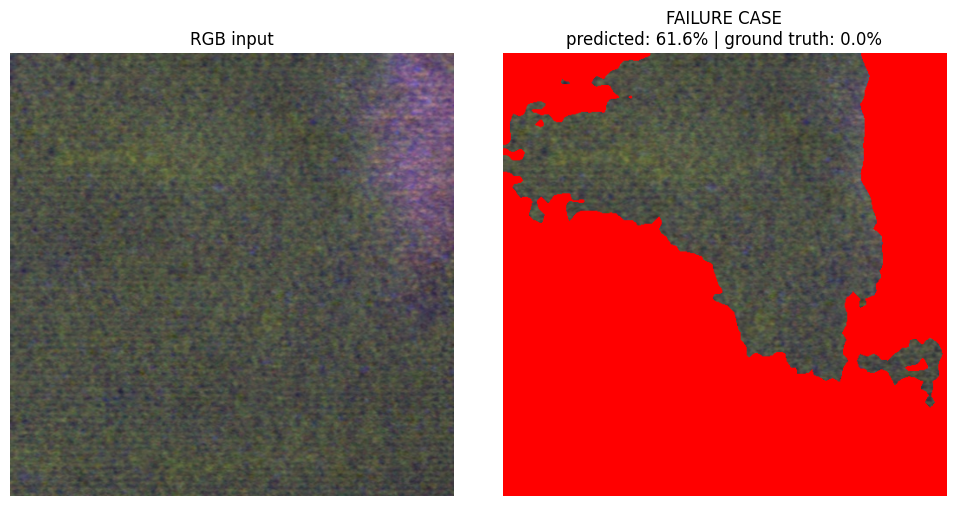

saved: /content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/sample_results/A8FDGVE6I_9020-1185-9532-1697_result.png


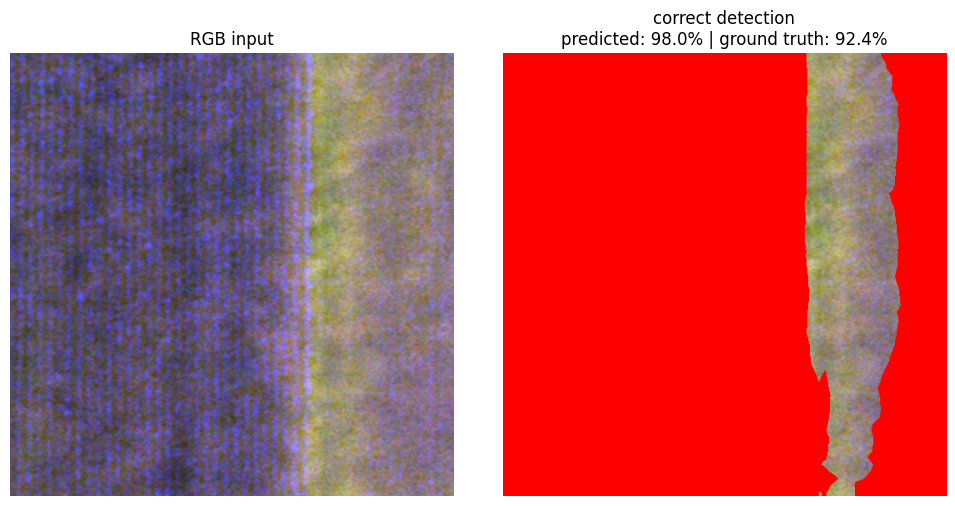

saved: /content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/sample_results/83JHJFB7H_6351-4749-6863-5261_result.png


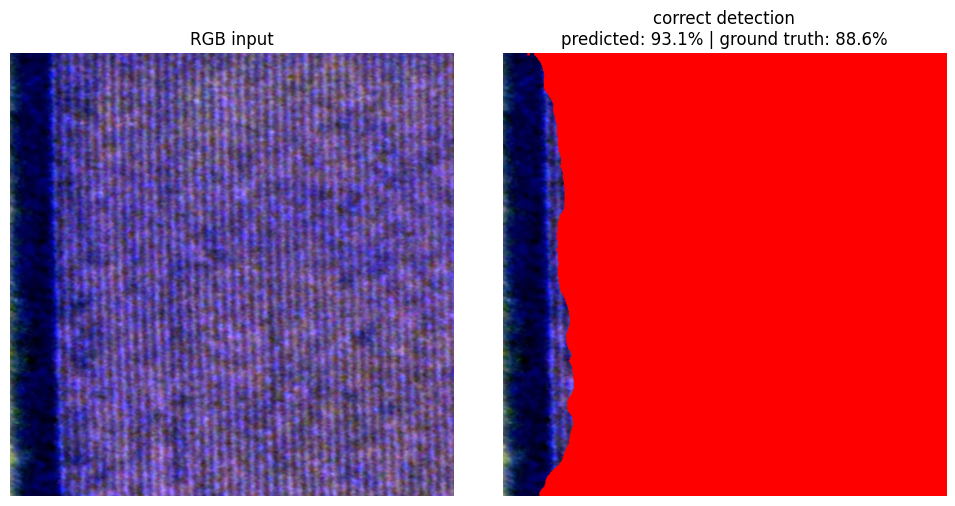

saved: /content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/sample_results/DQXE6IG9V_776-2694-1288-3206_result.png


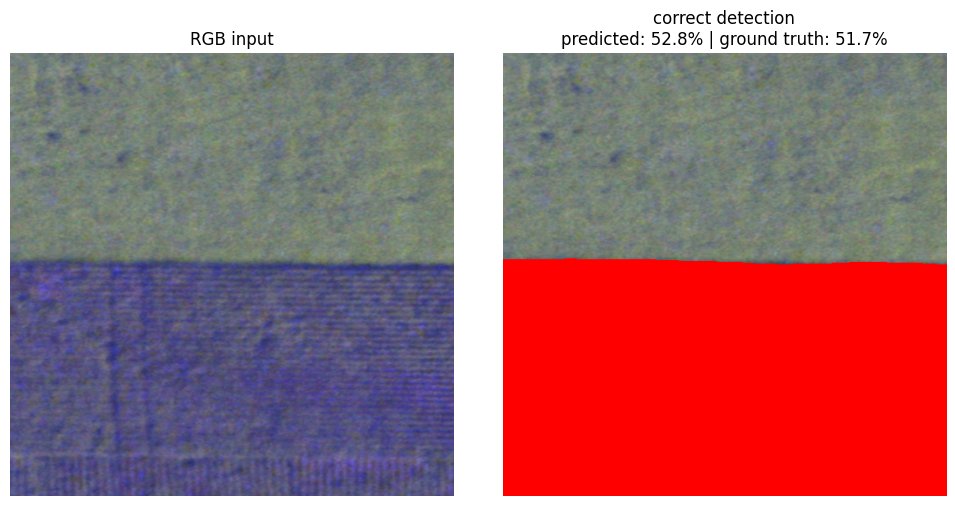

saved: /content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/sample_results/L7I3I7YTR_12126-4096-12638-4608_result.png


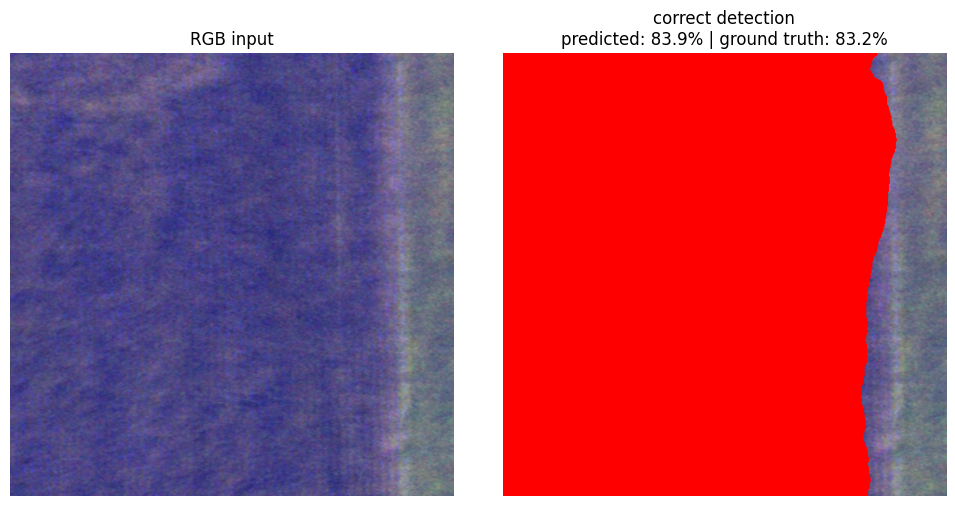

saved: /content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/sample_results/H76EWLPT7_4701-4703-5213-5215_result.png

total sample results saved: 5


In [40]:
OUT_DIR = CONFIG["sample_out_dir"]
os.makedirs(OUT_DIR, exist_ok=True)

failure_case = fp_rates[0][0]  # worst false alarm -- the required "at least 1 wrong" case
good_cases = [f for f, _ in pos_results[-4:]]  # highest-IoU genuine detections
selected = [failure_case] + good_cases

for fname in selected:
    stem = fname.replace(".png", "")
    idx = test_files.index(fname)

    hwc = load_tiff_chw_to_hwc(f"{test_dir}/{stem}.tiff")
    rgb = hwc[:, :, :3]

    pred_mask = (all_test_preds[idx] * 255).astype(np.uint8)

    gt = np.array(Image.open(f"{test_mask_dir}/{stem}.png"))
    valid_area = (gt != 255)
    pct_predicted = (pred_mask[valid_area] > 0).mean() * 100
    pct_ground_truth = (gt[valid_area] == 1).mean() * 100

    overlay = rgb.copy()
    overlay[pred_mask > 0] = [255, 0, 0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(rgb)
    axes[0].set_title("RGB input")
    axes[0].axis("off")
    axes[1].imshow(overlay)
    tag = "FAILURE CASE" if fname == failure_case else "correct detection"
    axes[1].set_title(f"{tag}\npredicted: {pct_predicted:.1f}% | ground truth: {pct_ground_truth:.1f}%")
    axes[1].axis("off")
    plt.tight_layout()

    out_path = f"{OUT_DIR}/{stem}_result.png"
    plt.savefig(out_path, dpi=100, bbox_inches="tight")
    plt.show()
    print(f"saved: {out_path}")

print(f"\ntotal sample results saved: {len(os.listdir(OUT_DIR))}")